In [2]:
import polars as pl
import pyarrow as pa

print("polars version:", pl.__version__)
print("pyarrow version:", pa.__version__)

polars version: 1.36.1
pyarrow version: 21.0.0


In [4]:
park_tick = pl.read_csv(
    "/Users/allysonlopez/UCI/Datathon 2026/Parking_Citations_.csv",
    infer_schema_length=10000,
    ignore_errors=True
)
print(park_tick.shape)
print(park_tick.dtypes)

(24307581, 8)
[String, String, String, String, String, String, Float64, Float64]


In [5]:
print(park_tick.columns)
park_tick.head(5)

['issue_date', 'issue_time', 'make', 'body_style', 'violation_description', 'fine_amount', 'loc_lat', 'loc_long']


issue_date,issue_time,make,body_style,violation_description,fine_amount,loc_lat,loc_long
str,str,str,str,str,str,f64,f64
"""2025 Apr 26 12:00:00 AM""","""904""","""FORD""","""PA""","""DOUBLE PARKING""","""68""",34.038267,-118.299593
"""2025 Apr 26 12:00:00 AM""","""830""","""CHEV""","""PA""","""FIRE HYDRANT""","""68""",34.16337,-118.431059
"""2025 Apr 26 12:00:00 AM""","""825""","""TOYT""","""PA""","""METER EXP.""","""63""",34.052868,-118.260923
"""2025 Apr 26 12:00:00 AM""","""935""","""CHEV""","""PU""","""STANDNG IN ALLEY""","""68""",33.788801,-118.304095
"""2025 Apr 26 12:00:00 AM""","""1,255""","""NISS""","""PA""","""EXCEED 72HRS-ST""","""68""",34.208873,-118.592801


In [6]:
park_tick = park_tick.with_columns([
    # Clean and parse issue_time (remove commas, convert to int)
    pl.col("issue_time")
      .str.replace_all(",", "")
      .cast(pl.Int32, strict=False)
      .alias("issue_time"),

    # Clean fine_amount
    pl.col("fine_amount")
      .str.replace_all(",", "")
      .cast(pl.Float64, strict=False)
      .alias("fine_amount"),

    # Parse issue_date
    pl.col("issue_date")
      .str.strptime(pl.Date, "%Y %b %d %I:%M:%S %p", strict=False)
      .alias("issue_date"),
]).with_columns([
    # Derive time features after parsing
    pl.col("issue_date").dt.month().alias("issue_month"),
    pl.col("issue_date").dt.weekday().alias("issue_dow"),
    pl.col("issue_date").dt.year().alias("issue_year"),
    (pl.col("issue_time") / 100).floor().cast(pl.Int32).alias("issue_hour"),
])

park_tick.head(5)

issue_date,issue_time,make,body_style,violation_description,fine_amount,loc_lat,loc_long,issue_month,issue_dow,issue_year,issue_hour
date,i32,str,str,str,f64,f64,f64,i8,i8,i32,i32
2025-04-26,904,"""FORD""","""PA""","""DOUBLE PARKING""",68.0,34.038267,-118.299593,4,6,2025,9
2025-04-26,830,"""CHEV""","""PA""","""FIRE HYDRANT""",68.0,34.16337,-118.431059,4,6,2025,8
2025-04-26,825,"""TOYT""","""PA""","""METER EXP.""",63.0,34.052868,-118.260923,4,6,2025,8
2025-04-26,935,"""CHEV""","""PU""","""STANDNG IN ALLEY""",68.0,33.788801,-118.304095,4,6,2025,9
2025-04-26,1255,"""NISS""","""PA""","""EXCEED 72HRS-ST""",68.0,34.208873,-118.592801,4,6,2025,12


In [7]:
print(park_tick.shape)
print(park_tick.null_count())

(24307581, 12)
shape: (1, 12)
┌────────────┬────────────┬───────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ issue_date ┆ issue_time ┆ make  ┆ body_style ┆ … ┆ issue_mon ┆ issue_dow ┆ issue_yea ┆ issue_hou │
│ ---        ┆ ---        ┆ ---   ┆ ---        ┆   ┆ th        ┆ ---       ┆ r         ┆ r         │
│ u32        ┆ u32        ┆ u32   ┆ u32        ┆   ┆ ---       ┆ u32       ┆ ---       ┆ ---       │
│            ┆            ┆       ┆            ┆   ┆ u32       ┆           ┆ u32       ┆ u32       │
╞════════════╪════════════╪═══════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0          ┆ 2405       ┆ 46807 ┆ 149352     ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 2405      │
└────────────┴────────────┴───────┴────────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [8]:
park_tick.group_by("violation_description").len().sort("len", descending=True).head(20)

violation_description,len
str,u32
"""NO PARK/STREET CLEAN""",6378538
"""METER EXP.""",4181117
"""RED ZONE""",2224302
"""PREFERENTIAL PARKING""",1761931
"""DISPLAY OF TABS""",1115831
…,…
"""DOUBLE PARKING""",253513
"""YELLOW ZONE""",238965
"""18 IN. CURB/2 WAY""",237162


In [9]:
park_tick.select("fine_amount").describe()

statistic,fine_amount
str,f64
"""count""",2.4167571e7
"""null_count""",140010.0
"""mean""",72.869825
"""std""",41.894797
"""min""",0.0
"""25%""",63.0
"""50%""",68.0
"""75%""",73.0
"""max""",1100.0


In [10]:
park_tick.group_by("issue_hour").len().sort("issue_hour")

issue_hour,len
i32,u32
null,2405
0,181780
1,508573
2,495840
3,279554
…,…
19,693907
20,415131
21,358518


In [11]:
park_tick.group_by("issue_dow").len().sort("issue_dow")

issue_dow,len
i8,u32
1,3750255
2,4486328
3,4275126
4,4410036
5,3926693
6,2314878
7,1144265


In [12]:
park_tick.group_by("make").len().sort("len", descending=True).head(15)

make,len
str,u32
"""TOYT""",4042926
"""HOND""",2771458
"""FORD""",2002541
"""NISS""",1712092
"""CHEV""",1639511
…,…
"""LEXS""",684663
"""KIA""",655569
"""JEEP""",606221


In [13]:
park_tick.group_by("issue_year").len().sort("issue_year")

issue_year,len
i32,u32
1950,1
1962,1
1970,1
1972,2
2000,10
…,…
2029,4
2030,4
2031,2


In [14]:
# Filter out bad years and null hours
park_tick_clean = park_tick.filter(
    pl.col("issue_year").is_between(2010, 2025),
    pl.col("issue_hour").is_not_null()
)

print(park_tick_clean.shape)

(24305063, 12)


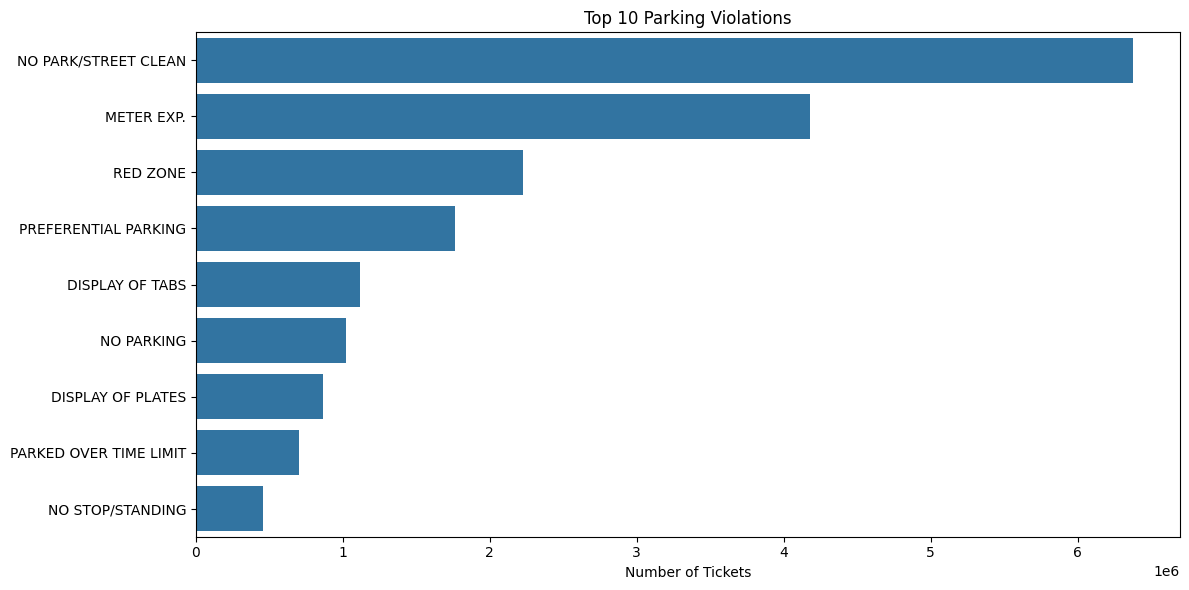

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 violations
top_violations = (
    park_tick_clean
    .group_by("violation_description")
    .len()
    .sort("len", descending=True)
    .head(10)
    .to_pandas()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_violations, x="len", y="violation_description")
plt.title("Top 10 Parking Violations")
plt.xlabel("Number of Tickets")
plt.ylabel("")
plt.tight_layout()
plt.show()

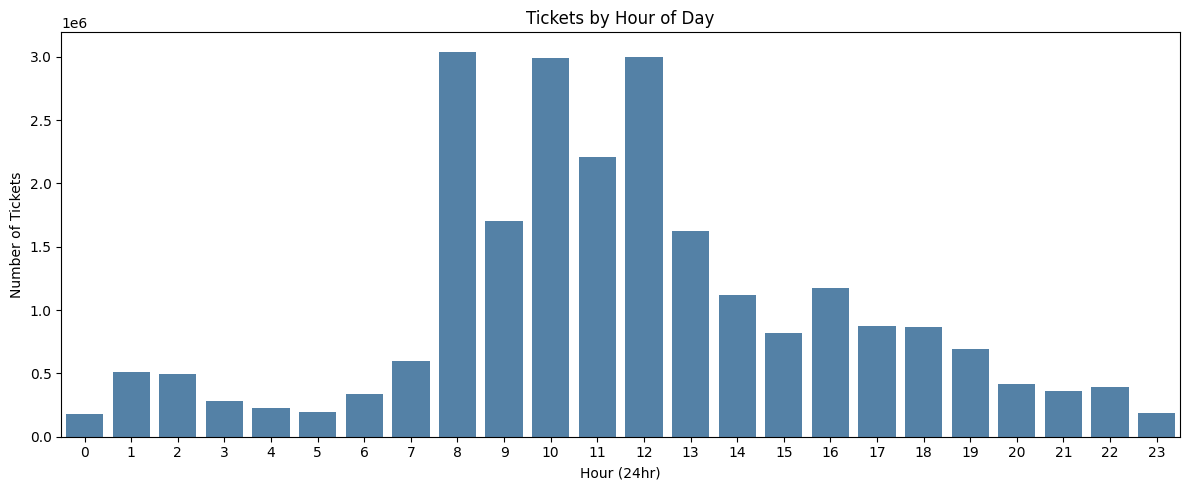

In [16]:
hourly = (
    park_tick_clean
    .group_by("issue_hour")
    .len()
    .sort("issue_hour")
    .to_pandas()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly, x="issue_hour", y="len", color="steelblue")
plt.title("Tickets by Hour of Day")
plt.xlabel("Hour (24hr)")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

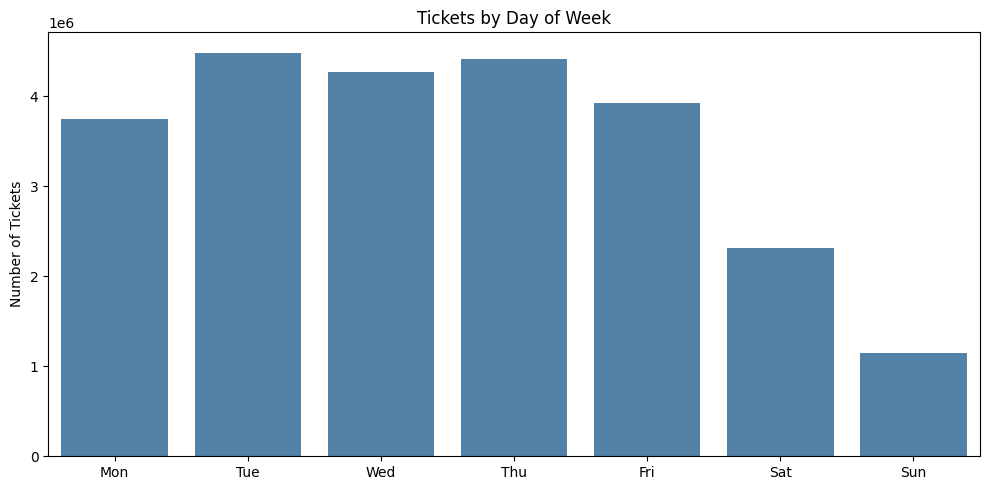

In [17]:
dow_labels = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

daily = (
    park_tick_clean
    .group_by("issue_dow")
    .len()
    .sort("issue_dow")
    .to_pandas()
)
daily["day_name"] = daily["issue_dow"].map(dow_labels)

plt.figure(figsize=(10, 5))
sns.barplot(data=daily, x="day_name", y="len", color="steelblue")
plt.title("Tickets by Day of Week")
plt.xlabel("")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

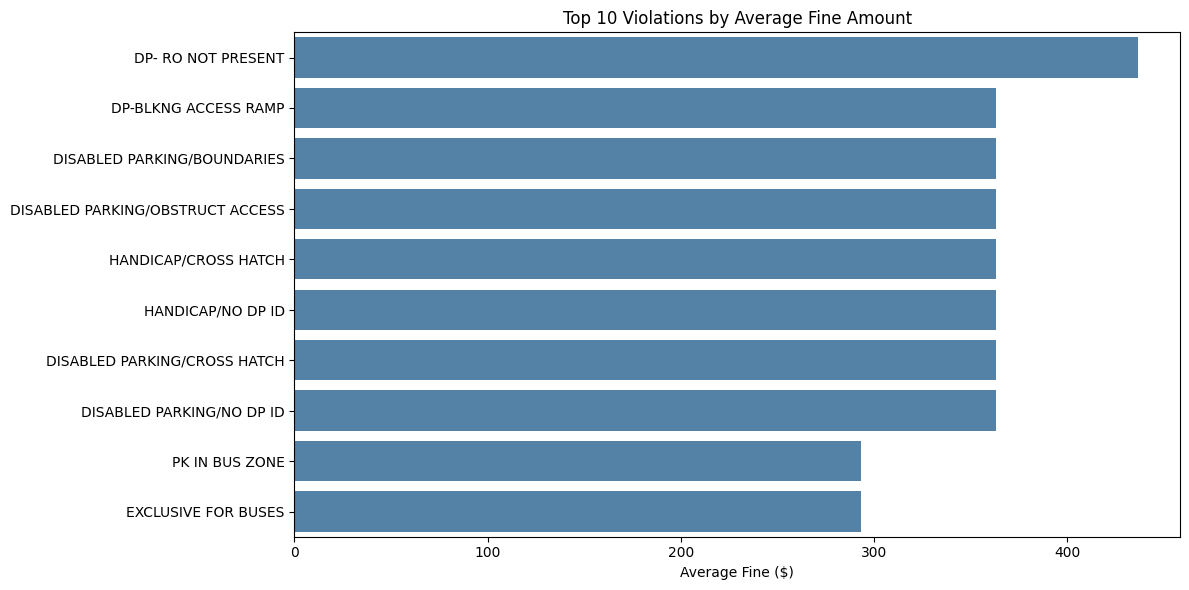

In [19]:
avg_fine = (
    park_tick_clean
    .filter(
        pl.col("violation_description").str.contains(r"^[A-Z][A-Z\s/\.\-]+$")
    )
    .group_by("violation_description")
    .agg(
        pl.col("fine_amount").mean().alias("avg_fine"),
        pl.len().alias("n")
    )
    .filter(pl.col("n") > 1000)  # only violations with meaningful volume
    .sort("avg_fine", descending=True)
    .head(10)
    .to_pandas()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_fine, x="avg_fine", y="violation_description", color="steelblue")
plt.title("Top 10 Violations by Average Fine Amount")
plt.xlabel("Average Fine ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

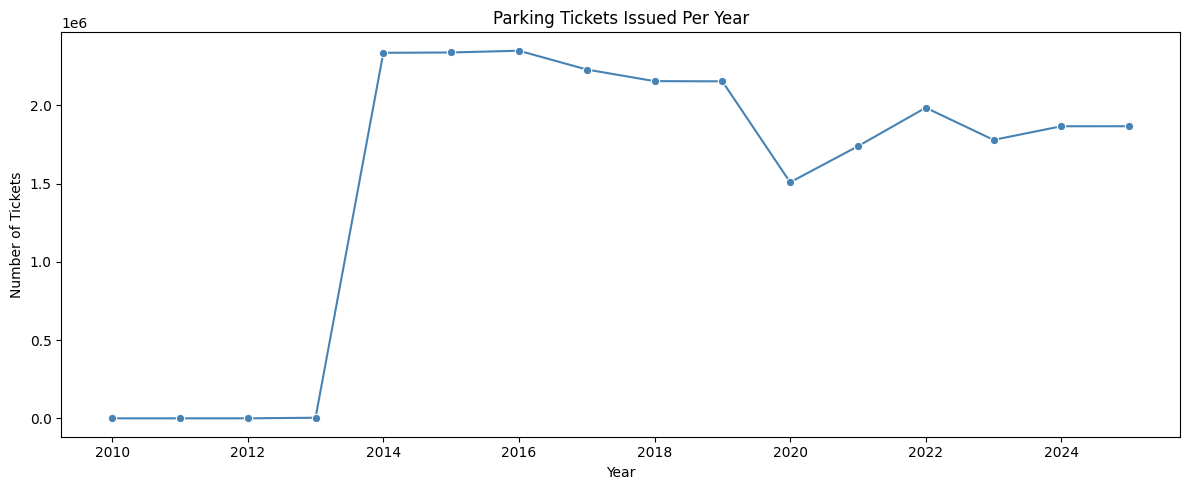

In [20]:
yearly = (
    park_tick_clean
    .group_by("issue_year")
    .len()
    .sort("issue_year")
    .to_pandas()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x="issue_year", y="len", marker="o", color="steelblue")
plt.title("Parking Tickets Issued Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

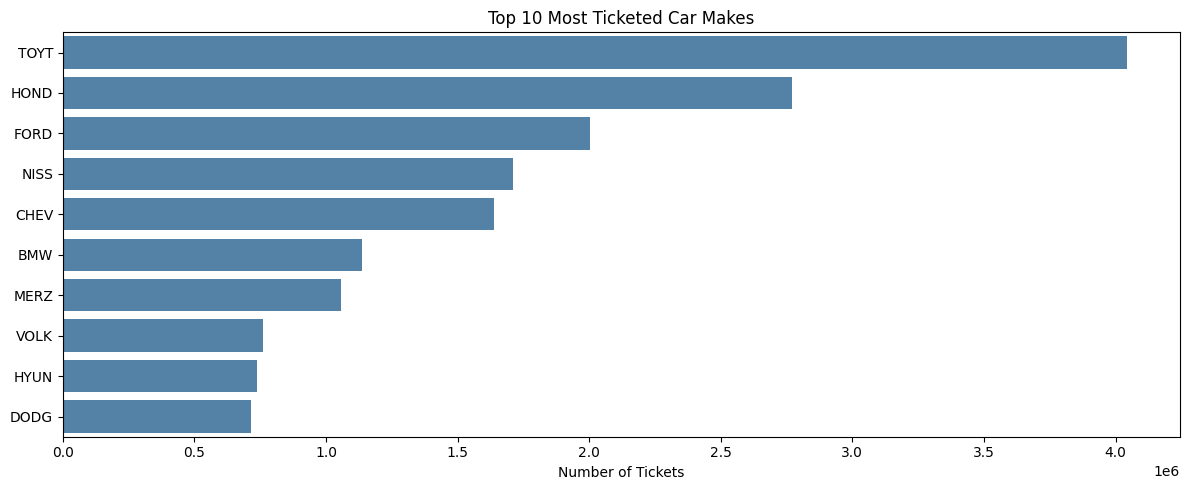

In [21]:
top_makes = (
    park_tick_clean
    .group_by("make")
    .len()
    .sort("len", descending=True)
    .head(10)
    .to_pandas()
)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_makes, x="len", y="make", color="steelblue")
plt.title("Top 10 Most Ticketed Car Makes")
plt.xlabel("Number of Tickets")
plt.ylabel("")
plt.tight_layout()
plt.show()

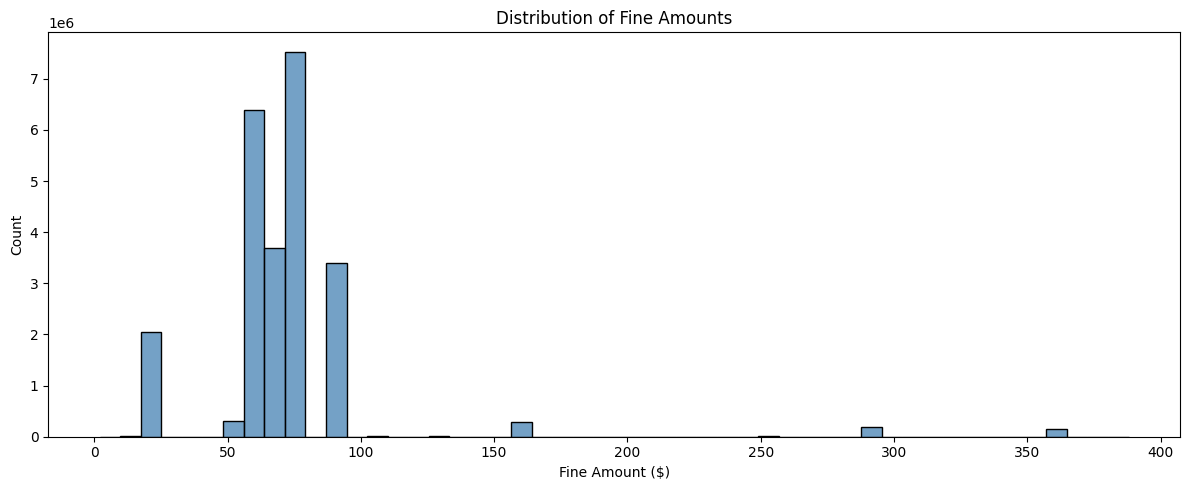

In [22]:
fine_data = park_tick_clean.filter(
    pl.col("fine_amount").is_not_null(),
    pl.col("fine_amount") > 0,
    pl.col("fine_amount") < 500
).select("fine_amount").to_pandas()

plt.figure(figsize=(12, 5))
sns.histplot(data=fine_data, x="fine_amount", bins=50, color="steelblue")
plt.title("Distribution of Fine Amounts")
plt.xlabel("Fine Amount ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

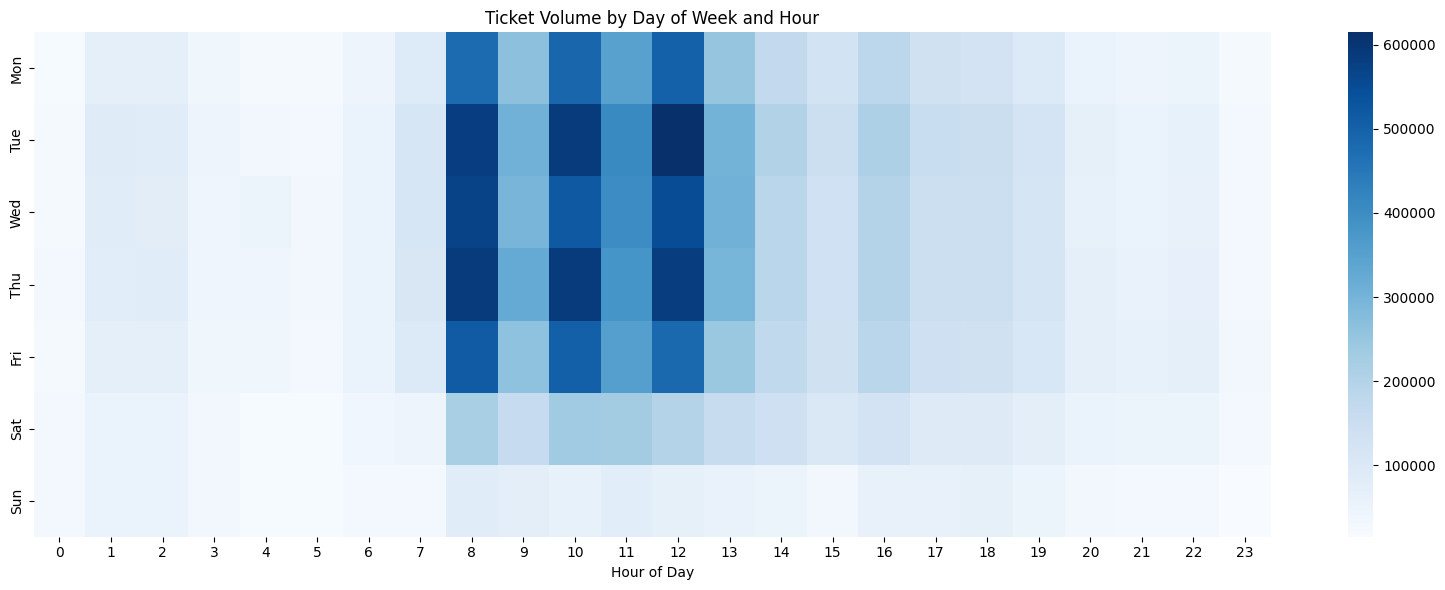

In [23]:
import numpy as np

heatmap_data = (
    park_tick_clean
    .group_by(["issue_dow", "issue_hour"])
    .len()
    .to_pandas()
)

heatmap_pivot = heatmap_data.pivot(index="issue_dow", columns="issue_hour", values="len")
heatmap_pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_pivot, cmap="Blues", fmt=".0f")
plt.title("Ticket Volume by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("")
plt.tight_layout()
plt.show()

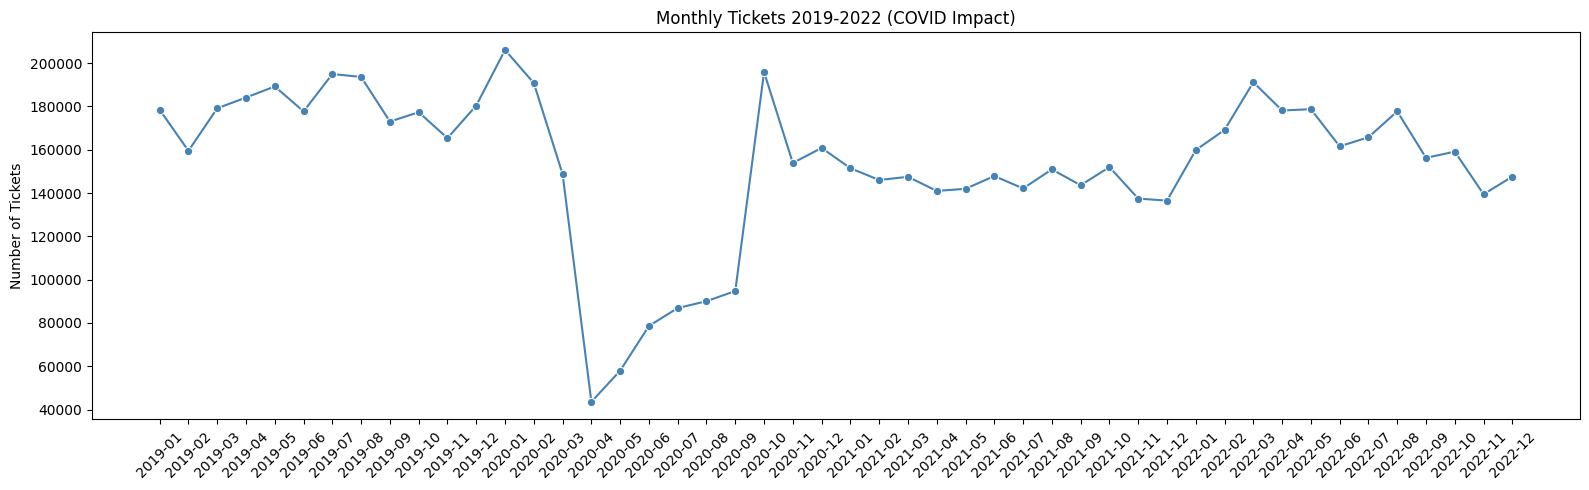

In [24]:
monthly = (
    park_tick_clean
    .filter(pl.col("issue_year").is_between(2019, 2022))
    .with_columns(
        (pl.col("issue_year").cast(str) + "-" + pl.col("issue_month").cast(str).str.zfill(2)).alias("year_month")
    )
    .group_by("year_month")
    .len()
    .sort("year_month")
    .to_pandas()
)

plt.figure(figsize=(16, 5))
sns.lineplot(data=monthly, x="year_month", y="len", marker="o", color="steelblue")
plt.title("Monthly Tickets 2019-2022 (COVID Impact)")
plt.xlabel("")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
import folium
from folium.plugins import HeatMap

# Sample down for performance — plotting all 24M points would crash
geo_sample = (
    park_tick_clean
    .filter(
        pl.col("loc_lat").is_not_null(),
        pl.col("loc_long").is_not_null(),
        pl.col("loc_lat") != 0,
        pl.col("loc_long") != 0
    )
    .sample(n=100000, seed=42)
    .select(["loc_lat", "loc_long"])
    .to_pandas()
)

# Create map centered on LA
m = folium.Map(location=[34.0522, -118.2437], zoom_start=11)

# Add heatmap layer
HeatMap(
    data=geo_sample[["loc_lat", "loc_long"]].values.tolist(),
    radius=8,
    blur=10,
    max_zoom=13
).add_to(m)

# Save as HTML file you can open in browser
m.save("/Users/allysonlopez/UCI/Datathon 2026/parking_heatmap.html")

print("Map saved! Open parking_heatmap.html in your browser")

/Users/allysonlopez/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Map saved! Open parking_heatmap.html in your browser
